<a href="https://colab.research.google.com/github/Wilson-G9/Lab5_Bai1_Tim_Mach/blob/main/Lab5_Bai1_Tim_Mach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 Bài 1: Dự đoán bệnh tim mạch
**Dataset:** Heartdisease.csv | **Thuật toán:** Logistic Regression, KNN, Random Forest

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

## Bước 1: Tải dữ liệu

In [ ]:
from google.colab import files
uploaded = files.upload()   # Upload Heartdisease.csv

df = pd.read_csv('Heartdisease.csv')
print("Shape:", df.shape)
print(df.head())
print(df.info())

Saving Heartdisease.csv to Heartdisease.csv
Shape: (303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 n

## Bước 2: Xử lý dữ liệu

Giá trị thiếu:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


/tmp/ipykernel_813/3322203644.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


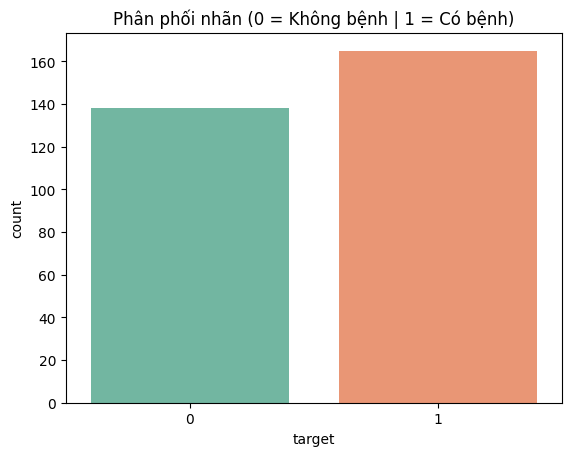

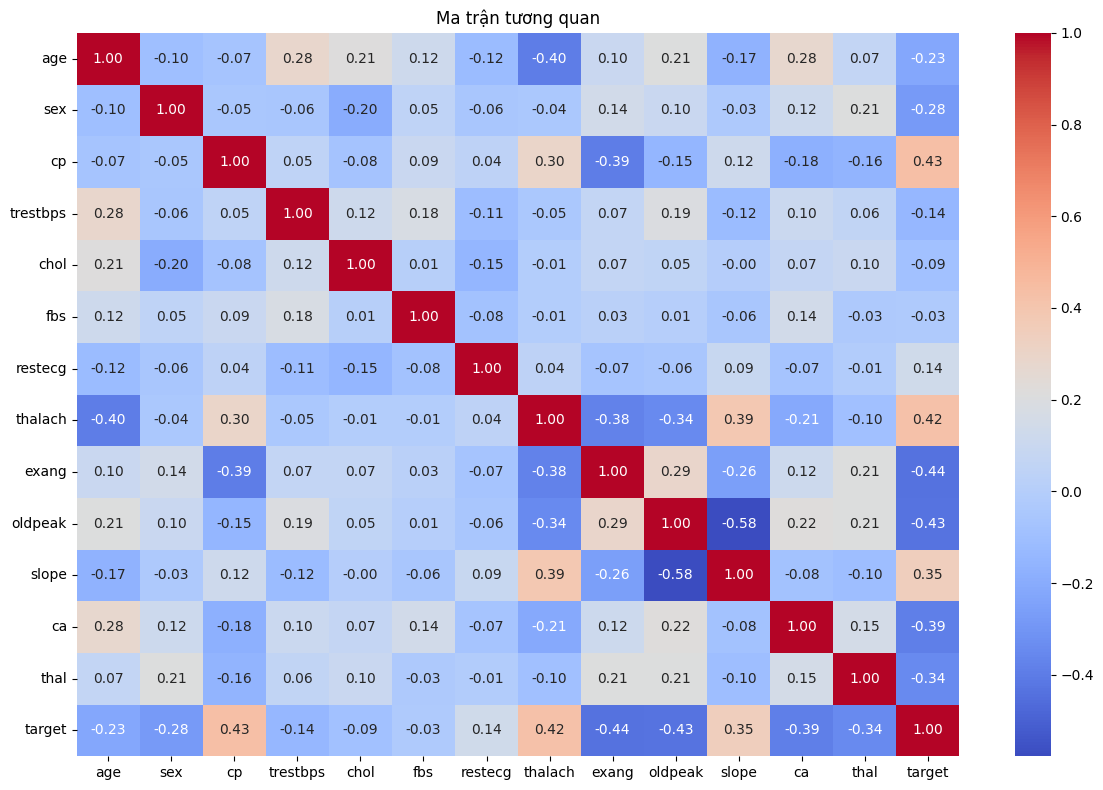

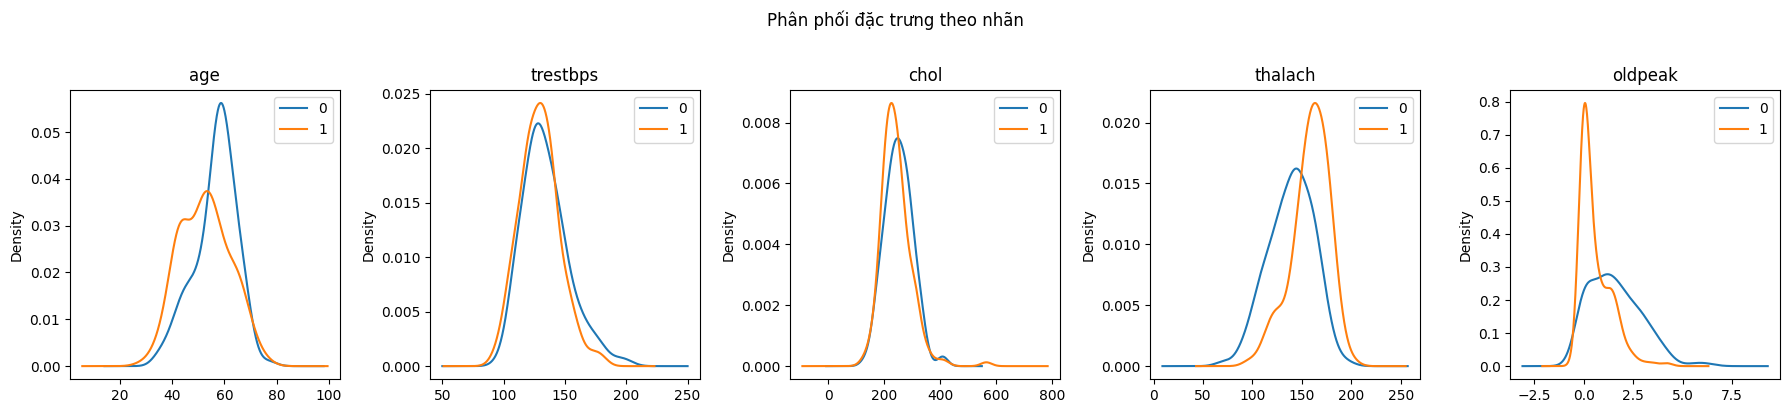

In [ ]:
print("Giá trị thiếu:\n", df.isnull().sum())
df.fillna(df.median(numeric_only=True), inplace=True)

# Phân phối target
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Phân phối nhãn (0 = Không bệnh | 1 = Có bệnh)')
plt.show()

# Heatmap tương quan
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()

# Phân phối đặc trưng theo nhãn
features_plot = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, len(features_plot), figsize=(18, 4))
for ax, feat in zip(axes, features_plot):
    df.groupby('target')[feat].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(feat)
plt.suptitle('Phân phối đặc trưng theo nhãn', y=1.02)
plt.tight_layout()
plt.show()

## Bước 3: Tách đặc trưng & chuẩn hóa

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (242, 13) | Test: (61, 13)


## Bước 4: Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)
print(f"[Logistic Regression] Accuracy: {lr_acc:.4f}")
print(classification_report(y_test, lr_pred, target_names=['Không bệnh', 'Có bệnh']))

[Logistic Regression] Accuracy: 0.8033
              precision    recall  f1-score   support

  Không bệnh       0.86      0.68      0.76        28
     Có bệnh       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



## Bước 5: K-Nearest Neighbors (KNN)

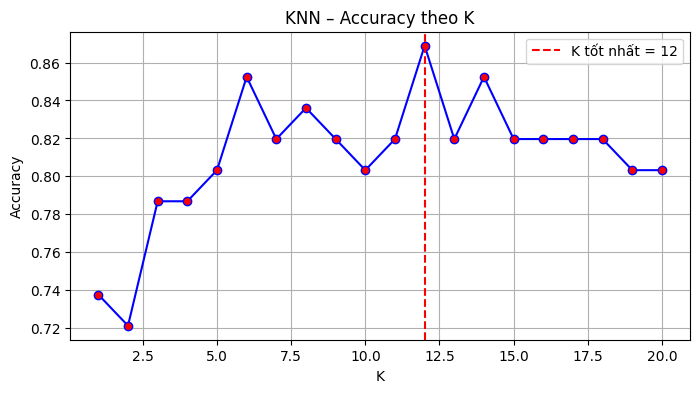

[KNN k=12] Accuracy: 0.8689
              precision    recall  f1-score   support

  Không bệnh       0.92      0.79      0.85        28
     Có bệnh       0.84      0.94      0.89        33

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.87        61
weighted avg       0.87      0.87      0.87        61



In [ ]:
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    k_scores.append(accuracy_score(y_test, knn.predict(X_test)))

best_k = np.argmax(k_scores) + 1
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), k_scores, 'bo-', markerfacecolor='red')
plt.axvline(best_k, color='red', linestyle='--', label=f'K tốt nhất = {best_k}')
plt.xlabel('K'); plt.ylabel('Accuracy')
plt.title('KNN – Accuracy theo K')
plt.legend(); plt.grid(True); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc  = accuracy_score(y_test, knn_pred)
print(f"[KNN k={best_k}] Accuracy: {knn_acc:.4f}")
print(classification_report(y_test, knn_pred, target_names=['Không bệnh', 'Có bệnh']))

## Bước 6: Random Forest

[Random Forest] Accuracy: 0.8361
              precision    recall  f1-score   support

  Không bệnh       0.95      0.68      0.79        28
     Có bệnh       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



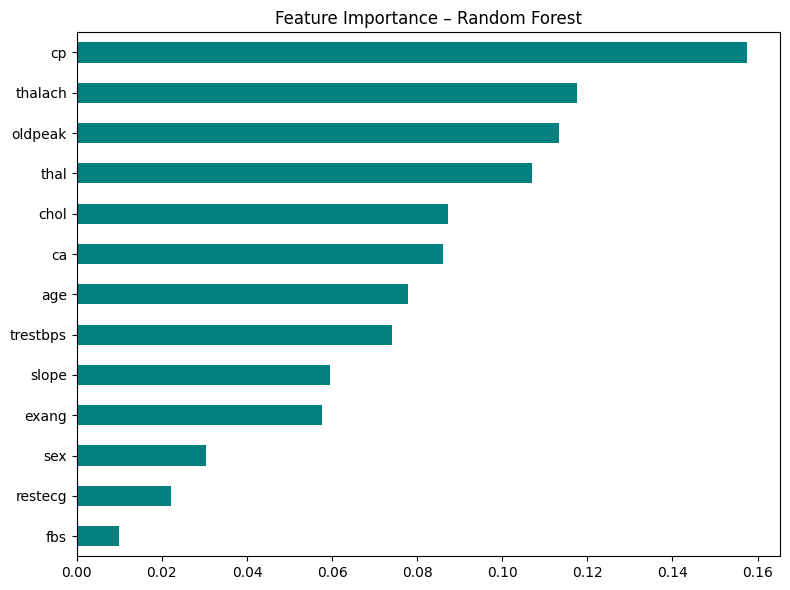

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"[Random Forest] Accuracy: {rf_acc:.4f}")
print(classification_report(y_test, rf_pred, target_names=['Không bệnh', 'Có bệnh']))

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', figsize=(8, 6), color='teal')
plt.title('Feature Importance – Random Forest')
plt.tight_layout(); plt.show()

## Bước 7: So sánh các mô hình

======= SO SÁNH ĐỘ CHÍNH XÁC =======
  Logistic Regression      : 80.33%
  KNN (k=12)               : 86.89%
  Random Forest            : 83.61%

✅ Mô hình tốt nhất: KNN (k=12) (86.89%)


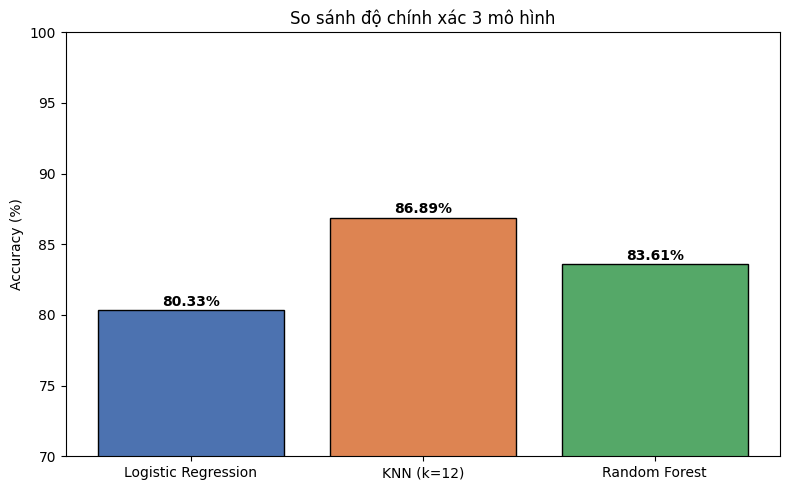

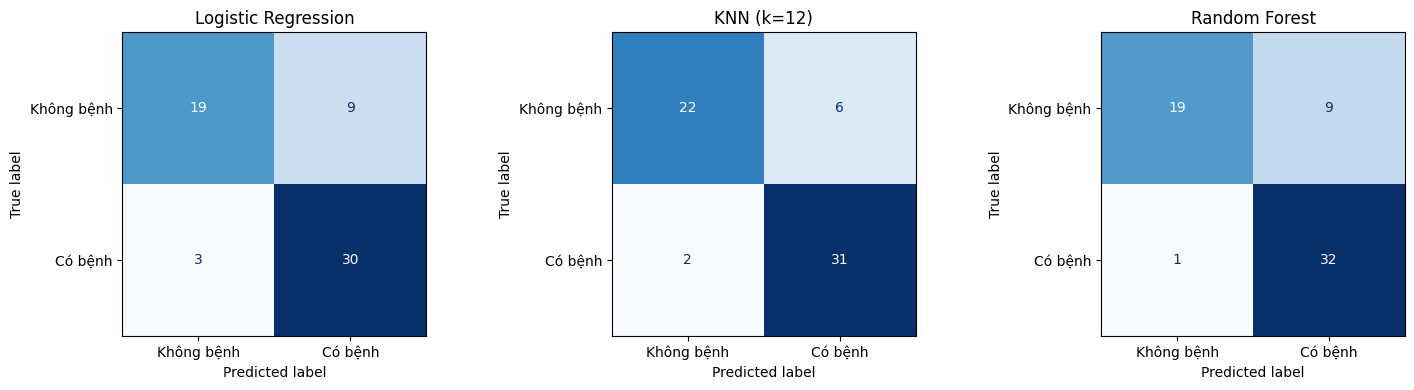

In [ ]:
results = {
    'Logistic Regression': lr_acc,
    f'KNN (k={best_k})':   knn_acc,
    'Random Forest':       rf_acc
}

print("======= SO SÁNH ĐỘ CHÍNH XÁC =======")
for name, acc in results.items():
    print(f"  {name:25s}: {acc*100:.2f}%")
best_name = max(results, key=results.get)
print(f"\n✅ Mô hình tốt nhất: {best_name} ({results[best_name]*100:.2f}%)")

# Biểu đồ cột
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), [v*100 for v in results.values()],
               color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{acc*100:.2f}%', ha='center', fontweight='bold')
plt.ylim(70, 100)
plt.ylabel('Accuracy (%)'); plt.title('So sánh độ chính xác 3 mô hình')
plt.tight_layout(); plt.show()

# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pred, name in zip(axes,
    [lr_pred, knn_pred, rf_pred],
    ['Logistic Regression', f'KNN (k={best_k})', 'Random Forest']):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
        display_labels=['Không bệnh', 'Có bệnh']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()